<a href="https://colab.research.google.com/github/KeerthipriyaJupaka/AI-Resume-Screening-System/blob/main/AI_Resume_Screening.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy scikit-learn joblib matplotlib seaborn


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import joblib

In [3]:
from google.colab import files

uploaded = files.upload()

Saving AI_Resume_Screening_Job_Market_Dataset_2026.csv to AI_Resume_Screening_Job_Market_Dataset_2026.csv


In [4]:
df = pd.read_csv("AI_Resume_Screening_Job_Market_Dataset_2026.csv")

df.head()

,candidate_id,job_title,industry,experience_years,education_level,skills_match_score,resume_score,location_type,salary_range_usd,ai_screening_result,interview_call,job_market_demand,year
0,C001,Data Scientist,IT,3,Master,82,85,Remote,70000-90000,Selected,Yes,High,2026
1,C002,Software Engineer,IT,1,Bachelor,65,70,Onsite,50000-65000,Rejected,No,High,2026
2,C003,ML Engineer,Finance,5,Master,90,92,Hybrid,90000-120000,Selected,Yes,High,2026
3,C004,Business Analyst,Healthcare,2,Bachelor,72,75,Onsite,55000-70000,Rejected,No,Medium,2026
4,C005,Data Analyst,E-commerce,4,Master,88,86,Remote,75000-95000,Selected,Yes,High,2026


In [6]:
print(df.shape)

df.info()

df.describe(include='all')
df.isnull().sum()

(5, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   candidate_id         5 non-null      object
 1   job_title            5 non-null      object
 2   industry             5 non-null      object
 3   experience_years     5 non-null      int64 
 4   education_level      5 non-null      object
 5   skills_match_score   5 non-null      int64 
 6   resume_score         5 non-null      int64 
 7   location_type        5 non-null      object
 8   salary_range_usd     5 non-null      object
 9   ai_screening_result  5 non-null      object
 10  interview_call       5 non-null      object
 11  job_market_demand    5 non-null      object
 12  year                 5 non-null      int64 
dtypes: int64(4), object(9)
memory usage: 652.0+ bytes


,0
candidate_id,0
job_title,0
industry,0
experience_years,0
education_level,0
skills_match_score,0
resume_score,0
location_type,0
salary_range_usd,0
ai_screening_result,0


In [7]:
encoders = {}

categorical_columns = df.select_dtypes(include=['object']).columns

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

df.head()

,candidate_id,job_title,industry,experience_years,education_level,skills_match_score,resume_score,location_type,salary_range_usd,ai_screening_result,interview_call,job_market_demand,year
0,0,2,3,3,1,82,85,2,2,1,1,0,2026
1,1,4,3,1,0,65,70,1,0,0,0,0,2026
2,2,3,1,5,1,90,92,0,4,1,1,0,2026
3,3,0,2,2,0,72,75,1,1,0,0,1,2026
4,4,1,0,4,1,88,86,2,3,1,1,0,2026


In [8]:
X = df.drop(["candidate_id", "interview_call"], axis=1)

y = df["interview_call"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [9]:
predictions = model.predict(X_test)

In [10]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


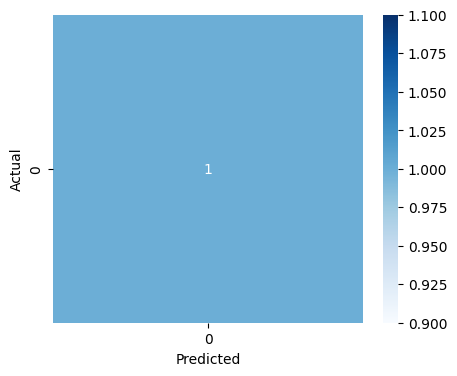

In [11]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [12]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1



In [13]:
joblib.dump(model, "model.pkl")
joblib.dump(encoders, "encoders.pkl")

print("Saved Successfully!")

Saved Successfully!


In [14]:
files.download("model.pkl")
files.download("encoders.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
!pip install pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 61.8 MB/s eta 0:00:00


In [16]:
import fitz
import re

In [17]:
from google.colab import files

uploaded = files.upload()

Saving Keerthpriya_Resume.pdf to Keerthpriya_Resume.pdf


In [18]:
filename = list(uploaded.keys())[0]

doc = fitz.open(filename)

text = ""

for page in doc:
    text += page.get_text()

print(text)

JUPAKA KEERTHI PRIYA
Email: jupakakeerthipriya@gmail.com
—
Phone: 6309478176
GitHub: https://github.com/jupakakeerthipriya
LinkedIn: https://www.linkedin.com/in/jupaka-keerthi-priya-942729325/
EDUCATION
Year
Degree/Certificate
Institute
CGPA/Percentage
2024–2028
B.Tech Computer Science
SR University
8.9
2024
Intermediate (12th)
TSWRS[G] Atmakur
80%
2022
SSC (10th)
TSWRS[G] Atmakur
9.5 GPA
PROJECTS
Multi-Level Stress Detection System
• Developed a real world project to detect stress levels using facial expressions, voice signals, and heart rate
data.
• Applied image processing for facial emotion recognition.
• Performed audio feature extraction for stress detection from voice.
• Integrated heart rate data to improve prediction accuracy.
• Used Python and real world techniques to classify stress into multiple levels.
Diabetic Retinopathy Detection
• Built a machine learning model to detect diabetic retinopathy from retinal images.
• Used image preprocessing and deep learning techniques f

In [19]:
skills = [
    "Python",
    "Java",
    "C",
    "C++",
    "SQL",
    "Machine Learning",
    "Deep Learning",
    "TensorFlow",
    "PyTorch",
    "Pandas",
    "NumPy",
    "Data Analysis",
    "Communication",
    "Leadership",
    "HTML",
    "CSS",
    "JavaScript",
    "React",
    "Node",
    "Git"
]

In [20]:
resume_text = text.lower()

found_skills = []

for skill in skills:
    if skill.lower() in resume_text:
        found_skills.append(skill)

print("Skills Found:")
print(found_skills)

Skills Found:
['Python', 'C', 'Machine Learning', 'Deep Learning', 'TensorFlow', 'Git']


In [21]:
score = len(found_skills) * 5

if score > 100:
    score = 100

print("Resume Score:", score)

Resume Score: 30


In [22]:
print("="*40)
print("AI Resume Screening Report")
print("="*40)

print("Skills Found:")
for skill in found_skills:
    print("-", skill)

print()

print("Resume Score:", score)

if score >= 80:
    print("Excellent Resume")
elif score >= 60:
    print("Good Resume")
elif score >= 40:
    print("Average Resume")
else:
    print("Needs Improvement")

AI Resume Screening Report
Skills Found:
- Python
- C
- Machine Learning
- Deep Learning
- TensorFlow
- Git

Resume Score: 30
Needs Improvement
